# ANALISI CONVERGENZA NEURAL NETWORK

### importazioni

In [1]:
from ML_app.single_neuron import single_neuron as neural_network
from ML_app.cost_functions import sigmoide

In [2]:
import pickle as pkl
import numpy as np

with open('../data/ottani_NIR.pkl', 'rb') as f:
    dizionario = pkl.load(f)
    
# dati train
train_ones = dizionario['train']['NIR']['ones']
train_zeros = dizionario['train']['NIR']['zeros']
train_labels = dizionario['train']['labels']
train_x = np.concatenate((train_zeros, train_ones))

# dati test
test_ones = dizionario['test']['NIR']['ones']
test_zeros = dizionario['test']['NIR']['zeros']
test_labels = dizionario['test']['labels']
test_x = np.concatenate((test_zeros, test_ones))

### SMOOTHING 

In [3]:
from scipy.signal import savgol_filter

window_size = 11
poly_order = 3

for i in range(train_x.shape[0]):
    train_x[i] = savgol_filter(train_x[i], window_size, poly_order)

for j in range(test_x.shape[0]):
    test_x[j] = savgol_filter(test_x[j], window_size, poly_order)

---

## neural network con PCA

In [4]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

In [5]:
max_epoche = 1_000_000

# normalizzazione
scaler = MinMaxScaler()
train_x = scaler.fit_transform(train_x)
test_x = scaler.transform(test_x)
# pca
pca = PCA(n_components=7)
train_x = pca.fit_transform(train_x)
test_x = pca.transform(test_x)
# estimator
nn_est = neural_network(
    epoche = max_epoche,
    nn_learning_rate = 0.5,
    activation_function = 'sigmoide',
    return_errors = True,
    convergence_tol = 1e-04
)


In [6]:
nn_est.fit(train_x, train_labels)
print(f'converged: {nn_est._has_converged} | if yes in: {nn_est._convergence_idx}')
lista_somma_errori = nn_est.errors_

converged: True | if yes in: 895704


In [7]:
nn_est.errors_.shape

(895,)

### training

In [8]:
import matplotlib.pyplot as plt

#fig, ax = plt.subplots(1, 2, figsize=(20, 8), dpi=150)
'''
x = range(np.array(lista_ultimi_errori).shape[0])#[:1000]
y = np.array(lista_ultimi_errori)#[:1000]

plt.figure(figsize=(8,4), dpi=200)
plt.scatter(x,y)
plt.xlabel("Epoca")
plt.ylabel("MSE al termine epoca")'''

'\nx = range(np.array(lista_ultimi_errori).shape[0])#[:1000]\ny = np.array(lista_ultimi_errori)#[:1000]\n\nplt.figure(figsize=(8,4), dpi=200)\nplt.scatter(x,y)\nplt.xlabel("Epoca")\nplt.ylabel("MSE al termine epoca")'

In [38]:
np.savetxt("some-results/errori-single-nn.txt", lista_somma_errori)

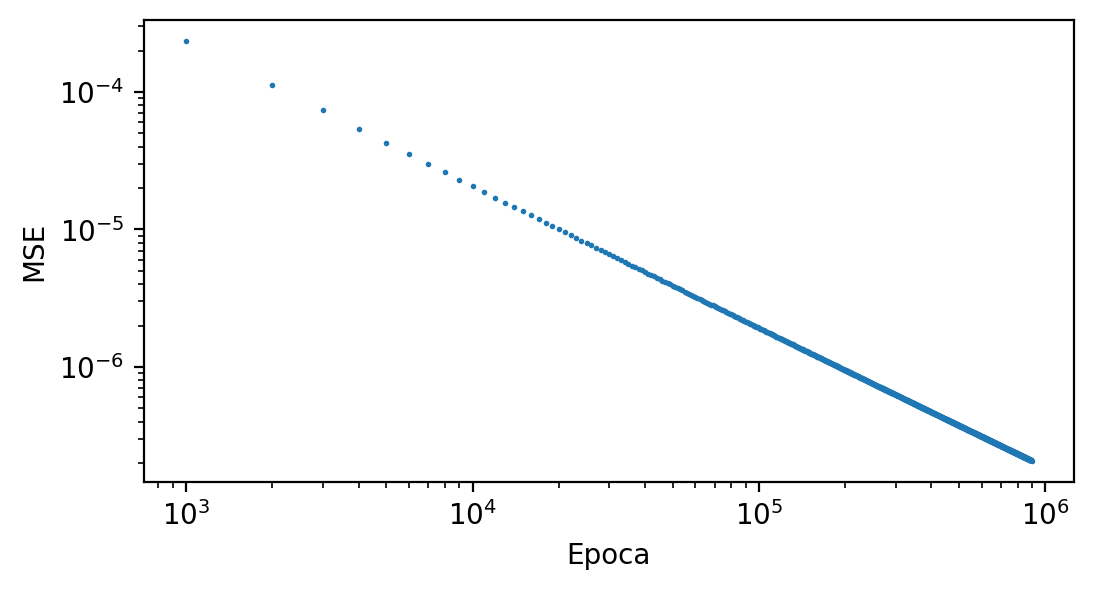

In [37]:
x = np.arange(0, 1000*len(lista_somma_errori), 1000) #[:1000]
y = np.array(lista_somma_errori)/480 #[:1000]

plt.figure(figsize=(6,3), dpi=200)
plt.scatter(x,y, s=1)
plt.xlabel("Epoca")
plt.xscale('log')
plt.ylabel("MSE")
plt.yscale('log')

### test

In [10]:
prediction = nn_est.predict(test_x)
prediction

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0])

studio convergenza: 9 minuti, ma la tol più piccola non è arrivata a convergenza

In [11]:
from subroutines import evaluate_lr_tol_convergence
from concurrent.futures import ProcessPoolExecutor

# parametri analisi
list_learning_rate = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]
n_iter = len(list_learning_rate)
max_epoche = [100_000_000]*n_iter
list_tolerance = [1e-04, 5e-04, 1e-03, 5e-03, 1e-02, 1e-01]

results = {}

for tol in list_tolerance:
    print(f'tol: {tol}')
    # Multiprocessing
    if __name__ == '__main__':
        print(f"Avvio analisi su {len(list_learning_rate)} learning rates in parallelo...")
        
        with ProcessPoolExecutor() as executor:
            # Passiamo i parametri usando una list comprehension o map
            # executor.map mantiene l'ordine della lista originale
            results[tol] = list(executor.map(
                evaluate_lr_tol_convergence, 
                max_epoche,
                list_learning_rate, 
                [tol]*n_iter,
                [train_x]*n_iter, 
                [train_labels]*n_iter,
            ))

print("Analisi completata.")


tol: 0.0001
Avvio analisi su 8 learning rates in parallelo...


tol: 0.0005
Avvio analisi su 8 learning rates in parallelo...
tol: 0.001
Avvio analisi su 8 learning rates in parallelo...
tol: 0.005
Avvio analisi su 8 learning rates in parallelo...
tol: 0.01
Avvio analisi su 8 learning rates in parallelo...
tol: 0.1
Avvio analisi su 8 learning rates in parallelo...
Analisi completata.


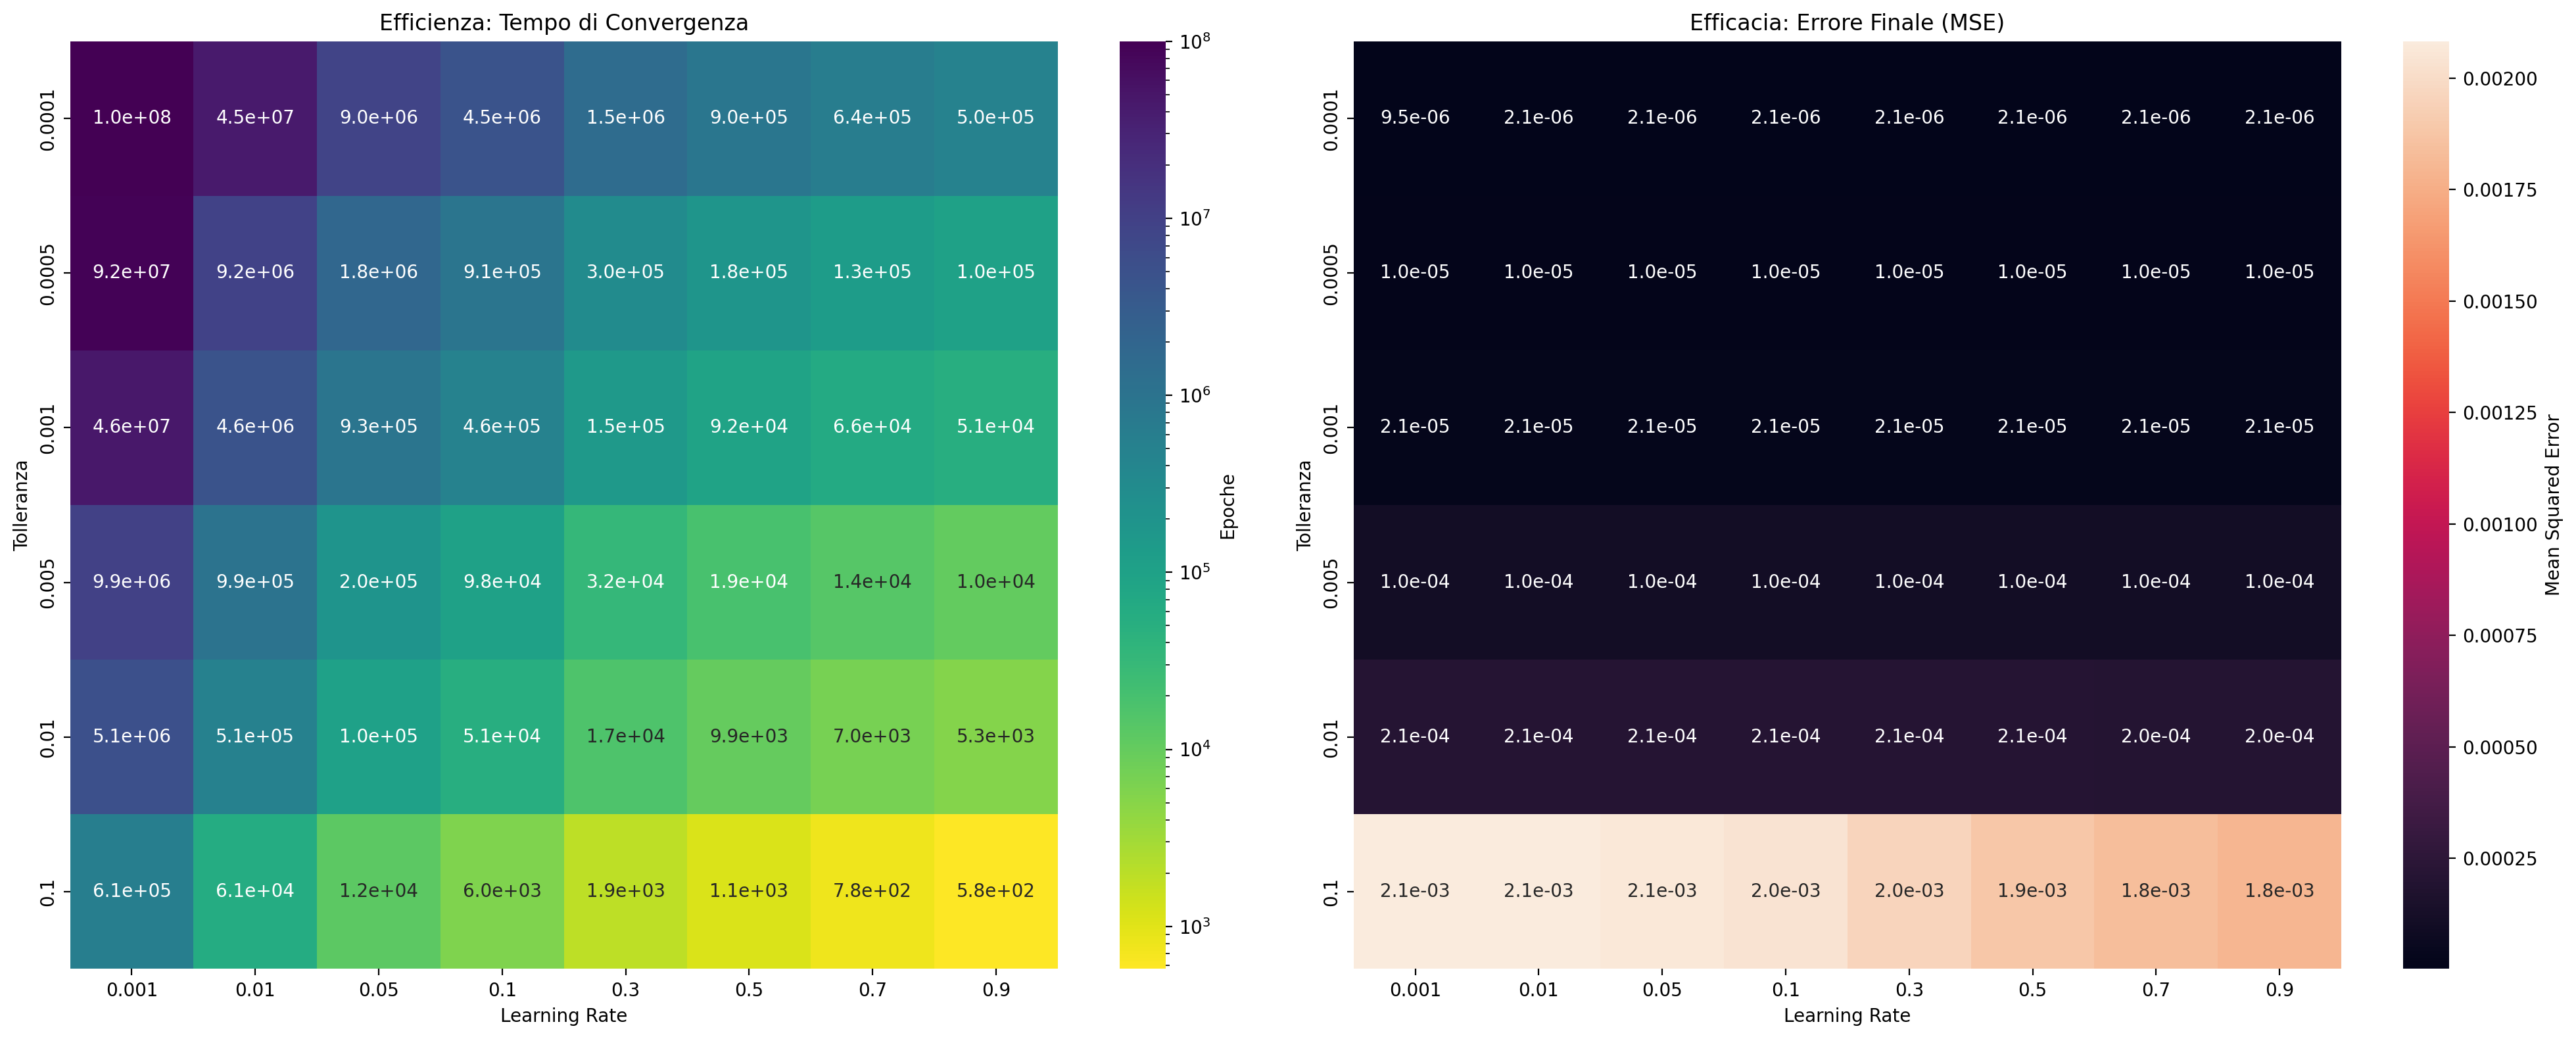

In [25]:
import pandas as pd
import seaborn as sns

# 1. Spacchettamento dei risultati
rows = []
for tol, list_tuple in results.items():
    for i, (epoche, mse, fit_time) in enumerate(list_tuple):
        rows.append({
            'Tolleranza': tol,
            'Learning Rate': list_learning_rate[i],
            'Epoche': epoche,
            'MSE': mse,
            'fit_time': fit_time
        })

df = pd.DataFrame(rows)

# 2. Creazione dei Pivot
pivot_epoche = df.pivot(index='Tolleranza', columns='Learning Rate', values='Epoche')
pivot_mse = df.pivot(index='Tolleranza', columns='Learning Rate', values='MSE')

# 3. Plotting affiancato
fig, ax = plt.subplots(1, 2, figsize=(20, 8), dpi=200)

# Heatmap 1: Epoche (Scala Logaritmica)
sns.heatmap(
    pivot_epoche, annot=True, fmt=".1e", cmap="viridis_r", ax=ax[0],
    norm=plt.matplotlib.colors.LogNorm(), cbar_kws={'label': 'Epoche'}
)
ax[0].set_title('Efficienza: Tempo di Convergenza')

# Heatmap 2: MSE (Scala Lineare o Log)
sns.heatmap(
    pivot_mse, annot=True, fmt=".1e", cmap="rocket", ax=ax[1],
    cbar_kws={'label': 'Mean Squared Error'}
)
ax[1].set_title('Efficacia: Errore Finale (MSE)')

plt.tight_layout()
plt.show()

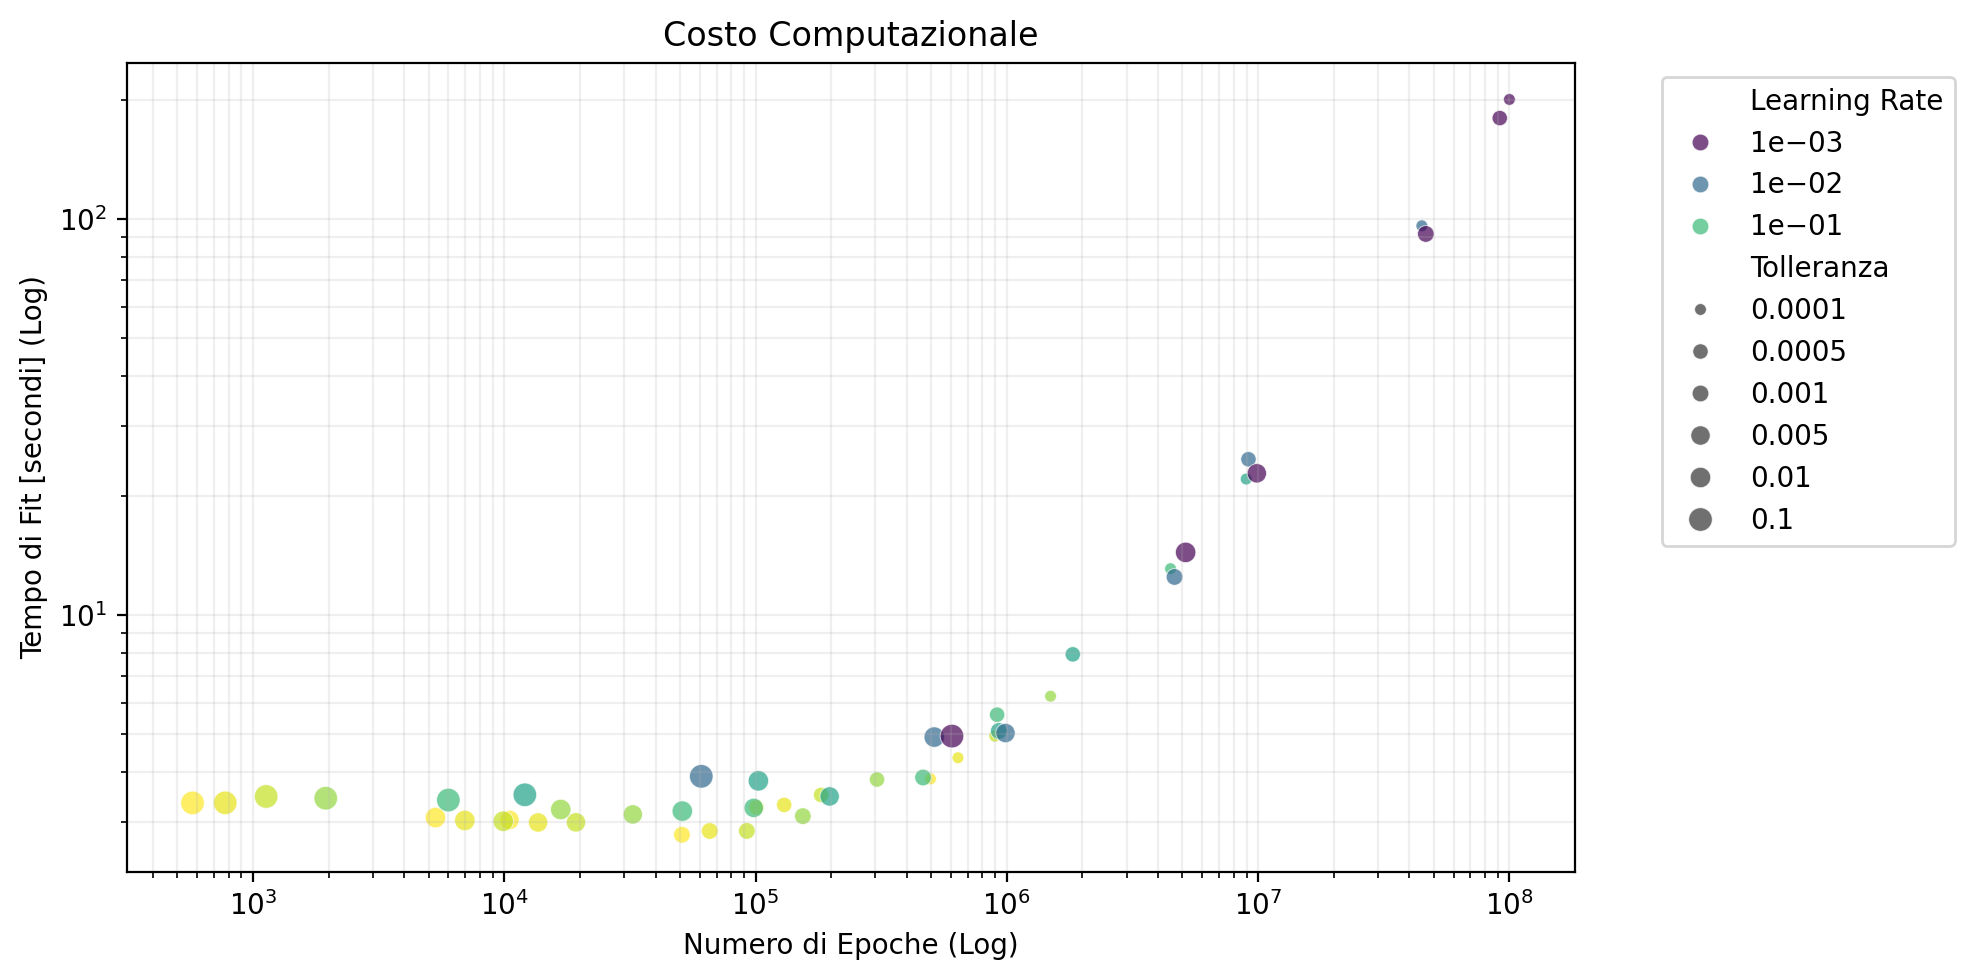

In [24]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(10, 5), dpi=200)

# Usiamo uno scatter plot per vedere la correlazione
sns.scatterplot(
    data=df, 
    x='Epoche', 
    y='fit_time', 
    hue='Learning Rate',      # Colora i punti in base al LR
    hue_norm=LogNorm(),
    size='Tolleranza',        # Dimensione in base alla tolleranza
    size_norm=LogNorm(),
    palette='viridis',
    alpha=0.7
)

# SCALA LOGARITMICA:
plt.xscale('log')
plt.yscale('log')

plt.grid(True, which="both", ls="-", alpha=0.2)
plt.xlabel('Numero di Epoche (Log)')
plt.ylabel('Tempo di Fit [secondi] (Log)')
plt.title('Costo Computazionale')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---